### I Hyperparameters

In [13]:
# environment

# buffer


# actor
ACTOR_HIDDEN_DIM = 64
ACTOR_HIDDEN_LAYER_COUNT = 0
ACTOR_LR = 1e-4

# critic
CRITIC_HIDDEN_DIM = 64
CRITIC_HIDDEN_LAYER_COUNT = 0
CRITIC_LR = 1e-3


### II Initialization

#### 1. Environment

In [14]:
from environment import Environment

env = Environment(
    render_mode="rgb_array",
)

env.reset()

agent_count = len(env.uavs)
state_dim = env.observation_space.shape[1]
action_dim = env.action_space.shape[1]

Show environment

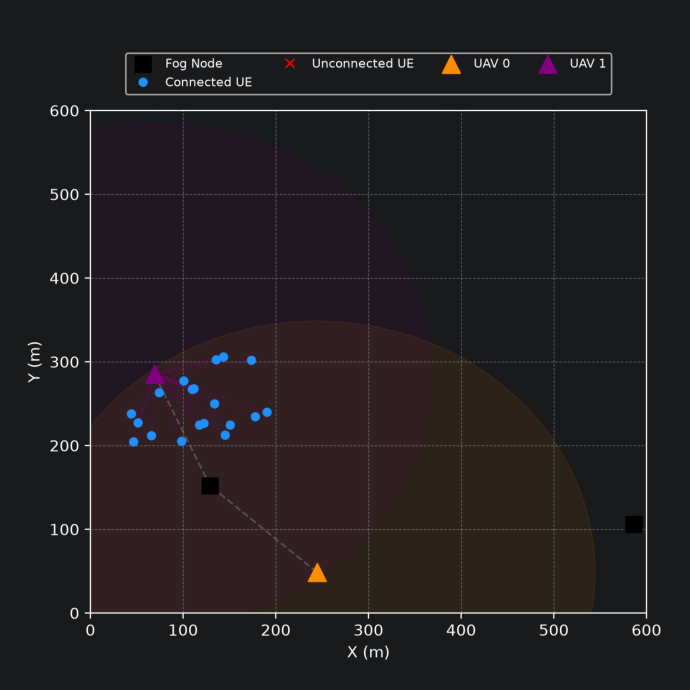

In [15]:
from matplotlib import pyplot as plt

img = env.render()
if img is not None:
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

#### 2. Algorithm

In [16]:
from algorithm import Algorithm
from utils import *
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
utils = Utils(device=device)

algorithm = Algorithm(
    algorithm="MADDPG",
    agent_count=agent_count,
    state_dim=state_dim,
    action_dim=action_dim,
    actor_hidden_dim=ACTOR_HIDDEN_DIM,
    critic_hidden_dim=CRITIC_HIDDEN_DIM,
    actor_hidden_layer_count=ACTOR_HIDDEN_LAYER_COUNT,
    critic_hidden_layer_count=CRITIC_HIDDEN_LAYER_COUNT,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    device=device,
    utils=utils,
)


### III Training

Hyperparameters

In [17]:
BATCH_SIZE = 128
EPISODE_COUNT = 200
TRAIN_INTERVAL = 1

Training loop

In [18]:
import numpy as np

PRINT_INTERVAL = 10

total_steps = 0
score_history = []
avg_scores = []

for episode in range(1, EPISODE_COUNT + 1):
    score = algorithm.explore(env=env)
    if total_steps % PRINT_INTERVAL == 0:
        algorithm.train()

    score_history.append(score)
    avg_score = float(np.mean(score_history[-100:]))
    if episode % PRINT_INTERVAL == 0 and episode > 0:
        print(f"Episode {episode}, Average Score: {avg_score:.1f}")
        avg_scores.append(avg_score)

Episode 10, Average Score: -60272.8
Episode 20, Average Score: -56698.2
Episode 30, Average Score: -57675.4
Episode 40, Average Score: -58773.2
Episode 50, Average Score: -58958.5
Episode 60, Average Score: -57594.5
Episode 70, Average Score: -56057.9
Episode 80, Average Score: -55572.9
Episode 90, Average Score: -54759.5
Episode 100, Average Score: -54225.9
Episode 110, Average Score: -53120.9
Episode 120, Average Score: -52559.3
Episode 130, Average Score: -51417.1
Episode 140, Average Score: -49901.2
Episode 150, Average Score: -48551.9
Episode 160, Average Score: -48407.1
Episode 170, Average Score: -49030.2
Episode 180, Average Score: -48685.7
Episode 190, Average Score: -48628.5
Episode 200, Average Score: -48417.7
